# 모터 감속기 신호 데이터 → 특징 벡터 변환 파이프라인

> 스펙트로그램 이미지(PNG)에서 머신러닝 입력용 **특징 벡터(feature vector)** 를 추출하는 전처리 과정입니다.

## 전체 흐름

```
PNG 스펙트로그램 이미지 로드
        ↓
픽셀값 NumPy 배열 변환  (행=주파수 bin, 열=시간 프레임)
        ↓
① 주파수 프로파일 생성   (Max)
        ↓
② 주파수 대역별 에너지   (Band Energy × 16)
        ↓
③ 주파수 피크 탐지        (find_peaks → Top 10)
        ↓
④ 전체 통계량              (mean, std, max, 95th, 99th)
        ↓
최종 특징 벡터 (67차원) → 머신러닝 모델 입력
```

In [2]:
!pip install Pillow

## 1단계: 데이터 불러오기

스펙트로그램 PNG 이미지를 **그레이스케일**로 읽어 NumPy 배열로 변환합니다.

- 이미지 크기: **높이(H) = 1280** (주파수 bin) × **너비(W) = 2000** (시간 프레임)
- 픽셀값(0~255): 해당 주파수·시간에서의 **에너지 크기**를 의미합니다
  - 255(흰색)에 가까울수록 에너지가 강함 / 0(검정)에 가까울수록 에너지가 약함

In [3]:
import numpy as np
from PIL import Image
from scipy.signal import find_peaks

# 스펙트로그램 PNG를 그레이스케일(L 모드)로 열기
# - 그레이스케일: 컬러(RGB)를 단일 밝기값(0~255)으로 변환
# - 밝기값 = 해당 주파수·시간 위치의 에너지 크기
img = Image.open(r"샘플데이터\Sample\01.원천데이터\1.모터_감속기\IONIQ\DEMAG\0728\Current_U\22_07_28_12_15_20_01_zsplit005_001_Current_U.png").convert("L")

# PIL Image → NumPy 배열 변환
# shape: (H=1280, W=2000) → 행(row) = 주파수 bin, 열(col) = 시간 프레임
arr = np.array(img)

print(arr)

[[149 147 144 ...  55  63  71]
 [149 147 144 ...  55  63  71]
 [149 147 144 ...  55  62  71]
 ...
 [178 171 163 ... 175 182 185]
 [178 171 163 ... 174 181 185]
 [178 171 163 ... 174 181 185]]


In [4]:
import matplotlib.pyplot as plt

## 2단계: 주파수 프로파일 생성

각 주파수 bin에서 **시간 축 전체를 하나의 값으로 요약**하여 1D 프로파일을 만듭니다.

| 프로파일 | 계산 방법 | 특징 |
|---|---|---|
| `freq_profile_max` | 시간 축 최댓값 (`axis=1`) | 짧은 순간(transient)의 피크도 보존 |

> **Max를 주로 사용하는 이유**: 결함 신호는 짧게 나타나는 경우가 많아, 평균을 내면 노이즈에 묻혀버릴 수 있습니다.

Text(0.5, 1.0, 'Frequency Profiles')

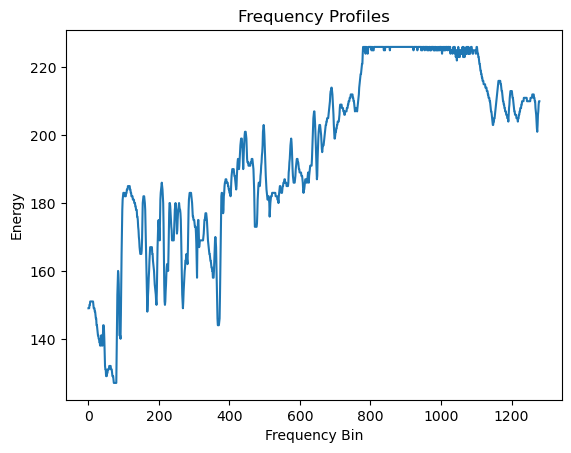

In [5]:
# 시간 축(axis=1, 열 방향)을 따라 집계 → 각 주파수 bin을 하나의 값으로 요약
freq_profile_max = arr.max(axis=1)   # shape: (1280,) | 순간 최대 에너지 (transient 피크 보존)

plt.plot(freq_profile_max, label='Max Profile')
plt.xlabel('Frequency Bin')
plt.ylabel('Energy')
plt.title('Frequency Profiles')

## 3단계: 주파수 대역별 에너지 분석 (Band Energy)

1280개 주파수 bin을 **16개 대역**으로 균등 분할하여 각 대역의 에너지를 계산합니다.  
(각 대역 = 80개 bin)

| 특징 | 변수 | 의미 |
|---|---|---|
| 평균 에너지 | `band_energy` | 해당 대역에 에너지가 얼마나 집중되어 있는가 |
| 에너지 변동성 | `band_energy_std` | 시간에 따라 에너지가 얼마나 불규칙한가 (클수록 결함 의심) |

> 선행연구에서 **1.2~1.8 kHz 대역**이 편심 결함과 관련 있다고 알려져 있습니다.

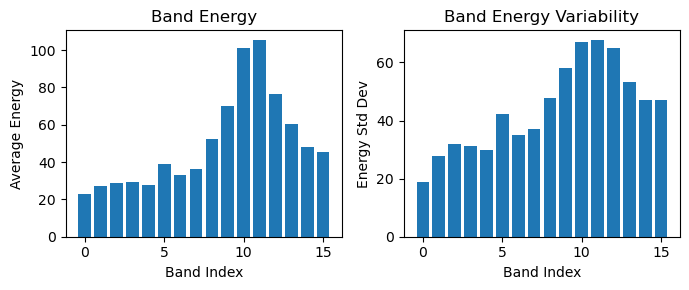

In [6]:
# 1280개 주파수 bin을 16개 대역으로 균등 분할 (각 대역 = 80 bins)
n_bands = 16
bands = np.array_split(arr, n_bands, axis=0)  # 주파수 축(axis=0, 행 방향)을 16등분

# 각 대역에서 에너지 크기(평균)와 시간 변동성(표준편차) 계산
band_energy     = np.array([b.mean() for b in bands])  # (16,) - 평균 에너지
band_energy_std = np.array([b.std()  for b in bands])  # (16,) - 에너지 변동성 (클수록 불규칙 → 결함 의심)

fig, axs = plt.subplots(1, 2, figsize=(7, 3))
axs[0].bar(range(n_bands), band_energy)
axs[0].set_xlabel('Band Index')
axs[0].set_ylabel('Average Energy')
axs[0].set_title('Band Energy')

axs[1].bar(range(n_bands), band_energy_std)
axs[1].set_xlabel('Band Index')
axs[1].set_ylabel('Energy Std Dev')
axs[1].set_title('Band Energy Variability')
plt.tight_layout()

## 4단계: 주파수 피크 탐지

`scipy.signal.find_peaks`로 max 프로파일에서 **두드러진 피크**를 찾습니다.

### 파라미터 설명

| 파라미터 | 값 | 의미 |
|---|---|---|
| `prominence` | 10 | 피크가 주변 골짜기보다 최소 10 이상 높아야 탐지 (작은 노이즈 피크 제거) |
| `distance` | 20 | 두 피크 사이 최소 간격 20 bin (너무 촘촘한 중복 피크 제거) |

### 반환값
- **`peaks`**: 피크가 위치한 주파수 bin 인덱스 배열
- **`props`**: 피크 속성 딕셔너리
  - `prominences`: 각 피크의 돌출 높이 (주변 골짜기 대비 높이 차이)
  - `left_bases` / `right_bases`: 피크의 왼쪽/오른쪽 기준점 인덱스

In [7]:
# find_peaks: max 프로파일에서 두드러진 피크를 탐지
# prominence=10 → 주변 골짜기보다 10 이상 높은 피크만 선택 (작은 노이즈 피크 제거)
# distance=20   → 인접 피크 간 최소 간격 20 bin (같은 피크가 중복 탐지되는 것 방지)
peaks, props = find_peaks(freq_profile_max, prominence=10, distance=20)

print("Detected Peaks at Frequency Bins:\n", peaks)
print()
print("Peak Prominences:\n", props['prominences'])

Detected Peaks at Frequency Bins:
 [  84  114  157  177  208  230  257  289  333  360  445  497  575  640
  689  798  823  848  888  927  957  984 1004 1035 1061 1101 1165]

Peak Prominences:
 [20. 37. 17. 17. 42. 30. 30. 34. 19. 12. 28. 27. 16. 20. 15. 25. 25. 25.
 25. 25. 25. 25. 25. 25. 25. 25. 13.]


### props 딕셔너리 내용 확인

`props`에는 각 피크의 상세 속성이 담겨 있습니다.  
`left_bases`, `right_bases`는 prominence 계산 시 참조한 왼쪽/오른쪽 기준점(골짜기)의 인덱스입니다.

In [8]:
props

{'prominences': array([20., 37., 17., 17., 42., 30., 30., 34., 19., 12., 28., 27., 16.,
        20., 15., 25., 25., 25., 25., 25., 25., 25., 25., 25., 25., 25.,
        13.]),
 'left_bases': array([  79,   79,  150,  167,   79,  217,  217,  268,  308,  355,   79,
          79,  514,   79,   79,   79,   79,   79,   79,   79,   79,   79,
          79,   79,   79,   79, 1148], dtype=int64),
 'right_bases': array([  91,  167,  167,  193,  367,  268,  268,  367,  367,  367,  472,
         514,  610,  648,  698, 1273, 1273, 1273, 1273, 1273, 1273, 1273,
        1273, 1273, 1273, 1273, 1273], dtype=int64)}

### 모든 피크 시각화

탐지된 전체 피크를 `'x'` 마커로 표시합니다.

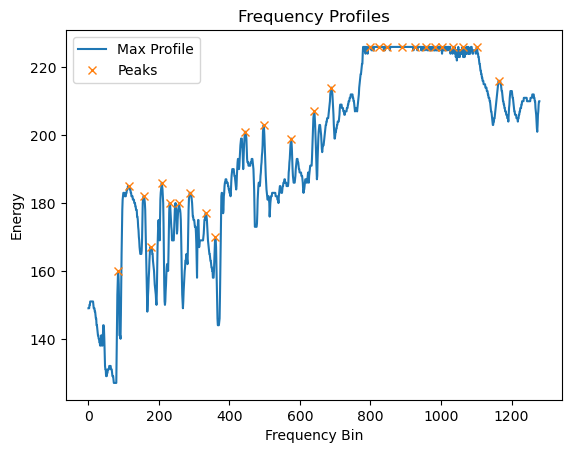

In [9]:
plt.plot(freq_profile_max, label='Max Profile')
plt.plot(peaks, freq_profile_max[peaks], 'x', label='Peaks')  # 'x' 마커: 탐지된 모든 피크 위치
plt.xlabel('Frequency Bin')
plt.ylabel('Energy')
plt.title('Frequency Profiles')
plt.legend()

### 상위 피크(Top-K) 선택

탐지된 피크 중 **prominence가 가장 큰 10개**를 선택합니다.

```
np.argsort(prominences)  → 오름차순 인덱스 정렬
[-10:]                   → 뒤에서 10개 = 상위 10개 (가장 두드러진 피크)
```

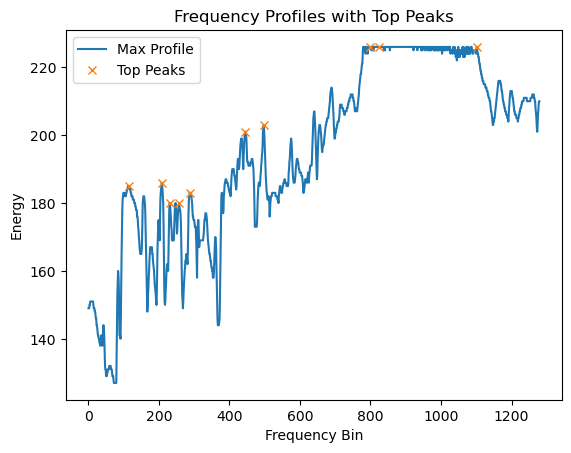

In [10]:
# np.argsort: prominence 오름차순 정렬 후 [-10:] 으로 뒤에서 10개 = 가장 두드러진 10개
top_k = np.argsort(props['prominences'])[-10:]

peak_freqs       = peaks[top_k]                     # 상위 피크의 주파수 bin 위치
peak_heights     = freq_profile_max[peaks[top_k]]   # 상위 피크의 에너지 값
peak_prominences = props['prominences'][top_k]       # 상위 피크의 돌출 정도

plt.plot(freq_profile_max, label='Max Profile')
plt.plot(peak_freqs, peak_heights, 'x', label='Top Peaks')  # 상위 10개 피크만 표시
plt.xlabel('Frequency Bin')
plt.ylabel('Energy')
plt.title('Frequency Profiles with Top Peaks')
plt.legend()

## 5단계: 통계량 계산

이미지 전체 픽셀에 대한 요약 통계량 **5개**를 계산합니다.

| 통계량 | 의미 |
|---|---|
| `mean` | 전체 평균 에너지 |
| `std` | 에너지 표준편차 (변동성) |
| `max` | 최대 에너지 값 |
| `95th percentile` | 상위 5% 기준 에너지 (극단값 정보) |
| `99th percentile` | 상위 1% 기준 에너지 (가장 강한 순간 에너지 포착) |

In [11]:
# 이미지 전체 픽셀에 대한 요약 통계량 5개
stats = [
    arr.mean(),             # 전체 평균 에너지
    arr.std(),              # 에너지 표준편차 (변동성)
    arr.max(),              # 최대 에너지 값
    np.percentile(arr, 95), # 상위 5% 에너지 임계값 (극단값 정보)
    np.percentile(arr, 99), # 상위 1% 에너지 임계값 (가장 강한 순간 포착)
]

## 6단계: 최종 특징 벡터 생성

앞서 계산한 모든 특징을 **하나의 1D 벡터**로 이어붙입니다(`np.concatenate`).

| 구성 요소 | 차원 | 설명 |
|---|---|---|
| `band_energy` | 16 | 대역별 평균 에너지 |
| `band_energy_std` | 16 | 대역별 에너지 변동성 |
| `peak_freqs` | 10 | 상위 피크 주파수 bin 위치 |
| `peak_heights` | 10 | 상위 피크 에너지 높이 |
| `peak_prominences` | 10 | 상위 피크 돌출 정도 |
| `stats` | 5 | 전체 통계량 |
| **합계** | **67** | **최종 특징 벡터 차원** |

이 **67차원 벡터**가 분류 모델(SVM, Random Forest 등)의 입력으로 사용됩니다.

In [12]:
# 모든 특징을 하나의 1D 벡터로 이어붙임
# 16 + 16 + 10 + 10 + 10 + 5 = 67차원
features = np.concatenate([
    band_energy,       # 16차원: 대역별 평균 에너지
    band_energy_std,   # 16차원: 대역별 에너지 변동성 (transient 포착)
    peak_freqs,        # 10차원: 상위 피크 주파수 bin 위치
    peak_heights,      # 10차원: 상위 피크 에너지 높이
    peak_prominences,  # 10차원: 상위 피크 돌출 정도
    stats,             #  5차원: 전체 통계량
])

In [13]:
features.shape

(67,)

In [14]:
features

array([  23.06203125,   27.0197625 ,   28.9713375 ,   29.48893125,
         27.88051875,   39.075025  ,   33.16759375,   36.4669875 ,
         52.18054375,   69.92985   ,  101.0291625 ,  105.33265   ,
         76.48375625,   60.59890625,   48.044375  ,   45.2315    ,
         18.88526796,   27.91591498,   31.79243567,   31.14820765,
         29.84063723,   42.11183855,   34.96284912,   37.05845261,
         47.65460324,   58.13607683,   66.90894213,   67.66561715,
         65.04354252,   53.17915045,   46.94737379,   47.06576723,
        798.        , 1101.        ,  823.        ,  497.        ,
        445.        ,  230.        ,  257.        ,  289.        ,
        114.        ,  208.        ,  226.        ,  226.        ,
        226.        ,  203.        ,  201.        ,  180.        ,
        180.        ,  183.        ,  185.        ,  186.        ,
         25.        ,   25.        ,   25.        ,   27.        ,
         28.        ,   30.        ,   30.        ,   34.     